In [181]:
import numpy as np 
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
#from sklearn.metrics import confusion_matrix
pd.set_option('display.max_columns', None)  #Gjør sånn at hele tabellen vises:)



# Datatilbredning

In [182]:
#lese inn data fra demographic
df_demographic = pd.read_csv("raw_data/demographic.csv")

In [183]:
#

income_mapping = {
    '$11-$25k': 1,
    'under $11k': 0,
    '$25k-$50k': 2,
    '$50k-$75k': 3,
    'above $75k': 4
}

df_demographic['inntekt'] = df_demographic['inntekt'].map(income_mapping)

#Gjør alle om til float
#df_demographic = df_demographic.astype(float)
df_demographic.head()

,pasient_id,alder,kjønn,utdanning,inntekt,etnisitet
0,2,60.33899,female,12.0,1.0,white
1,3,52.74698,female,12.0,0.0,white
2,4,42.38498,female,11.0,0.0,white
3,5,79.88495,female,NaN,NaN,white
4,6,93.01599,male,14.0,NaN,white


In [184]:
#leser inn data fra hospital 

df_hospital = pd.read_csv("raw_data/hospital.csv")

In [185]:
#fjerner alle med nagativ oppholdslengde
df_hospital = df_hospital[df_hospital['oppholdslengde'] >= 0]
df_hospital.head()

,pasient_id,sykehusdød,oppholdslengde
0,2,1,4
1,3,0,17
2,4,0,3
4,6,1,4
5,7,0,9


In [186]:
#leser inn data fra physiological
df_physiological = pd.read_csv("raw_data/physiological.txt", delimiter='\t')
df_physiological.head()

,pasient_id,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,bilirubin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde
0,2,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN
1,3,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN
2,4,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN
3,5,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN
4,6,110.0,10.398438,101.0,44.0,38.39844,266.62500,NaN,NaN,0.699951,140.0,7.659180,NaN,NaN,NaN


In [187]:
#leser inn data fra severity
df_severity = pd.read_json("raw_data/severity.json")

In [188]:
#legge det opp slik at hver pasient for riktig 
df_severity = df_severity.iloc[:, 0:-1].explode(list(df_severity.columns[2:-1]))
df_severity.reset_index(drop=True, inplace=True)
df_severity=df_severity.sort_values(by=['pasient_id'], ignore_index=True)

df_severity.head()





,sykdomskategori_id,sykdomskategori,pasient_id,dødsfall,sykdom_underkategori,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,kreft,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,dnr_status
0,BrY,COPD/CHF/Cirrhosis,2,1,Cirrhosis,2,44.0,None,1.0,52.695312,74.0,0.001,0.0,0,0,no,0.0,0.0,None
1,BrY,COPD/CHF/Cirrhosis,3,1,Cirrhosis,2,0.0,1.0,0.0,20.5,45.0,0.790894,0.664917,0,0,no,0.75,0.5,None
2,ChE,Cancer,4,1,Lung Cancer,2,0.0,0.0,0.0,20.097656,19.0,0.698975,0.411987,0,0,metastatic,0.9,0.5,None
3,A1s,ARF/MOSF,5,0,ARF/MOSF w/Sepsis,1,26.0,None,2.0,23.5,30.0,0.634888,0.532959,0,0,no,0.9,0.9,None
4,DWw,Coma,6,1,Coma,1,55.0,None,1.0,19.398438,27.0,0.284973,0.214996,0,0,no,0.0,0.0,None


## One Hot Encoder

For å gjøre alle kategoriske variabler om til numeriske

In [189]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohe_transformed_seveity = ohe.fit_transform(df_severity[['sykdomskategori_id','sykdomskategori', 'sykdom_underkategori', 'kreft', 'dnr_status']], )
df_severity = pd.concat([df_severity, ohe_transformed_seveity], axis=1).drop(columns = ['sykdomskategori_id','sykdomskategori', 'sykdom_underkategori', 'kreft', 'dnr_status'])

ohe_transformed_demographic = ohe.fit_transform(df_demographic[['kjønn', 'etnisitet']])
df_demographic = pd.concat([df_demographic, ohe_transformed_demographic], axis=1).drop(columns = ['kjønn', 'etnisitet'])

df_severity.head()

,pasient_id,dødsfall,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdomskategori_id_A1s,sykdomskategori_id_BrY,sykdomskategori_id_ChE,sykdomskategori_id_DWw,sykdomskategori_ARF/MOSF,sykdomskategori_COPD/CHF/Cirrhosis,sykdomskategori_Cancer,sykdomskategori_Coma,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,dnr_status_dnr før innleggelse,dnr_status_dnr ved innleggelse,dnr_status_None
0,2,1,2,44.0,None,1.0,52.695312,74.0,0.001,0.0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,3,1,2,0.0,1.0,0.0,20.5,45.0,0.790894,0.664917,0,0,0.75,0.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,4,1,2,0.0,0.0,0.0,20.097656,19.0,0.698975,0.411987,0,0,0.9,0.5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,5,0,1,26.0,None,2.0,23.5,30.0,0.634888,0.532959,0,0,0.9,0.9,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,6,1,1,55.0,None,1.0,19.398438,27.0,0.284973,0.214996,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# Merger datasett og fjerner duplikater

In [190]:
# Slår sammen df_severity og df_demographic
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error


df = pd.merge(df_severity, df_demographic, on='pasient_id', how='inner')

# Slår sammen det resultatet df_merged med df_hospital
df = pd.merge(df, df_hospital, on='pasient_id', how='inner')

# Slå sammen det resultatet med df_physiological
df = pd.merge(df, df_physiological, on='pasient_id', how='inner')

df = df.astype(float)

# Tell antall duplikater
antall_duplikater = df.duplicated().sum()

print("Antall duplikater i df_merged:", antall_duplikater)

#fjerne duplikater
df = df.drop_duplicates()

negativ_alder_count = (df['alder'] < 0).sum()

print("Antall pasienter med negativ alder i df_merged:", negativ_alder_count)

#Det er fem paisenter med negativ alder, derfor fjerner jeg de da det ikke vil gjøre noe stor forskjell i 

df = df[df['alder'] >= 0]




# Sjekk resultatet

df = df.drop(['sykdomskategori_id_A1s', 'sykdomskategori_id_BrY', 'sykdomskategori_id_ChE', 'sykdomskategori_id_DWw', 'sykdomskategori_ARF/MOSF', 'sykdomskategori_COPD/CHF/Cirrhosis', 'sykdomskategori_Cancer', 'sykdomskategori_Coma'], axis =1)

df.head()

Antall duplikater i df_merged: 2
Antall pasienter med negativ alder i df_merged: 5


,pasient_id,dødsfall,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,dnr_status_dnr før innleggelse,dnr_status_dnr ved innleggelse,dnr_status_None,alder,utdanning,inntekt,kjønn_female,kjønn_male,etnisitet_asian,etnisitet_black,etnisitet_hispanic,etnisitet_other,etnisitet_white,etnisitet_nan,sykehusdød,oppholdslengde,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,bilirubin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde
0,2.0,1.0,2.0,44.0,NaN,1.0,52.695312,74.0,0.001000,0.000000,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,60.33899,12.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN
1,3.0,1.0,2.0,0.0,1.0,0.0,20.500000,45.0,0.790894,0.664917,0.0,0.0,0.75,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,52.74698,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN
2,4.0,1.0,2.0,0.0,0.0,0.0,20.097656,19.0,0.698975,0.411987,0.0,0.0,0.90,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,42.38498,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN
4,6.0,1.0,1.0,55.0,NaN,1.0,19.398438,27.0,0.284973,0.214996,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,93.01599,14.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,110.0,10.398438,101.0,44.0,38.39844,266.62500,NaN,NaN,0.699951,140.0,7.659180,NaN,NaN,NaN
5,7.0,1.0,1.0,0.0,0.0,1.0,17.296875,46.0,0.892944,0.820923,0.0,0.0,NaN,0.7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,62.37097,14.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.0,78.0,11.699219,120.0,28.0,37.39844,309.50000,4.799805,0.399963,1.599854,132.0,7.479492,NaN,NaN,NaN


# Håndtering av NaN-verider

Finding missing values: 

In [191]:
print("Missing values in df_demographic is:\n", df.isnull().sum())

Missing values in df_demographic is:
 pasient_id                                   0
dødsfall                                     0
antall_komorbiditeter                        0
koma_score                                   0
adl_pasient                               4788
adl_stedfortreder                         2435
fysiologisk_score                            0
apache_fysiologisk_score                     0
overlevelsesestimat_2mnd                     0
overlevelsesestimat_6mnd                     0
diabetes                                     0
demens                                       0
lege_overlevelsesestimat_2mnd             1417
lege_overlevelsesestimat_6mnd             1403
sykdom_underkategori_ARF/MOSF w/Sepsis       0
sykdom_underkategori_CHF                     0
sykdom_underkategori_COPD                    0
sykdom_underkategori_Cirrhosis               0
sykdom_underkategori_Colon Cancer            0
sykdom_underkategori_Coma                    0
sykdom_underkategori_L

## Jeg endrer først på adl_pasient og adl_stedfortreder
Det er en indeks for daglig funksjonsaktivitet

In [192]:
df['adl'] = df['adl_pasient'].fillna(df['adl_stedfortreder'])
df.drop(['adl_pasient', 'adl_stedfortreder'], axis=1, inplace=True)
#Sjekker at det ikke lenger er NaN-verider, den er blitt mindre men har fortsatt 1758 NaN verdier
df.isnull().sum()

pasient_id                                   0
dødsfall                                     0
antall_komorbiditeter                        0
koma_score                                   0
fysiologisk_score                            0
apache_fysiologisk_score                     0
overlevelsesestimat_2mnd                     0
overlevelsesestimat_6mnd                     0
diabetes                                     0
demens                                       0
lege_overlevelsesestimat_2mnd             1417
lege_overlevelsesestimat_6mnd             1403
sykdom_underkategori_ARF/MOSF w/Sepsis       0
sykdom_underkategori_CHF                     0
sykdom_underkategori_COPD                    0
sykdom_underkategori_Cirrhosis               0
sykdom_underkategori_Colon Cancer            0
sykdom_underkategori_Coma                    0
sykdom_underkategori_Lung Cancer             0
sykdom_underkategori_MOSF w/Malig            0
kreft_metastatic                             0
kreft_no     

Setter inn anbefalte verider fra: https://archive.ics.uci.edu/dataset/880/support2

In [193]:
# Imputere manglende verdier 
df['serumalbumin'].fillna(3.5, inplace=True)
df['lungefunksjon'].fillna(333.3, inplace=True)
df['bilirubin'].fillna(1.01, inplace=True)
df['kreatinin'].fillna(1.01, inplace=True)
df['blodurea_nitrogen'].fillna(6.51, inplace=True)
df['hvite_blodlegemer'].fillna(9, inplace=True)
df['urinmengde'].fillna(2502, inplace=True)

df.isnull().sum()

/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_1484/3249217799.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_1484/3249217799.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

pasient_id                                   0
dødsfall                                     0
antall_komorbiditeter                        0
koma_score                                   0
fysiologisk_score                            0
apache_fysiologisk_score                     0
overlevelsesestimat_2mnd                     0
overlevelsesestimat_6mnd                     0
diabetes                                     0
demens                                       0
lege_overlevelsesestimat_2mnd             1417
lege_overlevelsesestimat_6mnd             1403
sykdom_underkategori_ARF/MOSF w/Sepsis       0
sykdom_underkategori_CHF                     0
sykdom_underkategori_COPD                    0
sykdom_underkategori_Cirrhosis               0
sykdom_underkategori_Colon Cancer            0
sykdom_underkategori_Coma                    0
sykdom_underkategori_Lung Cancer             0
sykdom_underkategori_MOSF w/Malig            0
kreft_metastatic                             0
kreft_no     

## Fjerner DNR status og DNR dag da dette ikke har noe med oppholdlengede å gjøre

In [194]:
df.drop(['dnr_status_dnr før innleggelse','dnr_status_dnr ved innleggelse', 'dnr_status_None'], axis=1, inplace=True)

#Vis med korrelasjon mellom de to og oppholdslengde

#Verifiserer at de er vekke
df.columns

Index(['pasient_id', 'dødsfall', 'antall_komorbiditeter', 'koma_score',
       'fysiologisk_score', 'apache_fysiologisk_score',
       'overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 'diabetes',
       'demens', 'lege_overlevelsesestimat_2mnd',
       'lege_overlevelsesestimat_6mnd',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_no', 'kreft_yes', 'alder', 'utdanning',
       'inntekt', 'kjønn_female', 'kjønn_male', 'etnisitet_asian',
       'etnisitet_black', 'etnisitet_hispanic', 'etnisitet_other',
       'etnisitet_white', 'etnisitet_nan', 'sykehusdød', 'oppholdslengde',
       'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'lungefunksjon

In [195]:
df.drop('bilirubin', axis=1, inplace= True)
df.columns

Index(['pasient_id', 'dødsfall', 'antall_komorbiditeter', 'koma_score',
       'fysiologisk_score', 'apache_fysiologisk_score',
       'overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 'diabetes',
       'demens', 'lege_overlevelsesestimat_2mnd',
       'lege_overlevelsesestimat_6mnd',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_no', 'kreft_yes', 'alder', 'utdanning',
       'inntekt', 'kjønn_female', 'kjønn_male', 'etnisitet_asian',
       'etnisitet_black', 'etnisitet_hispanic', 'etnisitet_other',
       'etnisitet_white', 'etnisitet_nan', 'sykehusdød', 'oppholdslengde',
       'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'lungefunksjon

## Fjerner dødsfall da det ikke har noe med oppholdslengde å gjøre

In [196]:
df.drop('dødsfall', axis = 1, inplace = True)

df.columns

Index(['pasient_id', 'antall_komorbiditeter', 'koma_score',
       'fysiologisk_score', 'apache_fysiologisk_score',
       'overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 'diabetes',
       'demens', 'lege_overlevelsesestimat_2mnd',
       'lege_overlevelsesestimat_6mnd',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_no', 'kreft_yes', 'alder', 'utdanning',
       'inntekt', 'kjønn_female', 'kjønn_male', 'etnisitet_asian',
       'etnisitet_black', 'etnisitet_hispanic', 'etnisitet_other',
       'etnisitet_white', 'etnisitet_nan', 'sykehusdød', 'oppholdslengde',
       'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'lungefunksjon',
       's

## Oppretter nytt df med den vaskede daten

In [197]:
df.to_csv("vasket_data.csv", index = False)

## Deler inn i treningsdata, valideringsdata og testdata

In [198]:

train_df, rest_df = train_test_split(df, test_size = 0.3 , random_state = 42)
val_df, test_df = train_test_split(rest_df, test_size = 0.5 , random_state = 42)

# Utforskende dataanalyse

Lag Korrelasjonmatrise 


korrelasjon fysiologisk score og oppholdslengde

Korrelasjon oppholdslengde og alder

## Statistisk beskrivelse av variablene i datasettet 

In [199]:
df.describe()

,pasient_id,antall_komorbiditeter,koma_score,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,alder,utdanning,inntekt,kjønn_female,kjønn_male,etnisitet_asian,etnisitet_black,etnisitet_hispanic,etnisitet_other,etnisitet_white,etnisitet_nan,sykehusdød,oppholdslengde,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde,adl
count,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,6312.000000,6326.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,6351.000000,3736.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,7729.000000,5820.000000,3916.000000,7729.000000,7729.000000,5975.000000
mean,4545.742916,1.868288,12.209600,25.567483,37.756890,0.634084,0.518326,0.196144,0.033510,0.616510,0.497391,0.387760,0.152154,0.105188,0.053435,0.056670,0.065080,0.100142,0.079570,0.204166,0.657006,0.138828,62.750226,11.752322,0.351445,0.435244,0.564756,0.008410,0.151507,0.032863,0.011774,0.790788,0.004658,0.263165,17.813042,84.428581,12.228507,97.248764,23.340018,37.115028,263.199475,3.154079,1.784702,137.574848,7.415406,160.021195,20.157448,2353.654146,1.529372
std,2633.543184,1.343641,24.761456,9.974890,20.086949,0.249395,0.254222,0.397105,0.179976,0.299461,0.304834,0.487271,0.359194,0.306816,0.224914,0.231225,0.246682,0.300209,0.270645,0.403117,0.474740,0.345789,15.611111,3.460267,0.477486,0.495821,0.495821,0.091325,0.358566,0.178290,0.107874,0.406772,0.068093,0.440380,21.739318,27.723064,9.021518,31.486704,9.547923,1.257040,103.416726,0.754653,1.706617,6.031115,0.080855,87.837826,23.371251,1011.576379,2.137028
min,2.000000,0.000000,0.000000,0.199982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.041990,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,31.699220,12.000000,0.399963,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000
25%,2254.000000,1.000000,0.000000,19.000000,23.000000,0.501953,0.337952,0.000000,0.000000,0.500000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.944980,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,63.000000,7.000000,72.000000,18.000000,36.195310,179.000000,2.699707,0.899902,134.000000,7.379883,103.000000,6.510000,2050.000000,0.000000
50%,4544.000000,2.000000,0.000000,24.000000,35.000000,0.713989,0.570923,0.000000,0.000000,0.700000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,65.015990,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.000000,77.000000,10.398438,100.000000,24.000000,36.695310,276.187500,3.500000,1.199951,137.000000,7.419922,135.000000,6.510000,2502.000000,0.000000
75%,6818.000000,3.000000,9.000000,30.199219,49.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,74.135990,14.000000,1.000000,1.000000,1.0

## Beskrivelse av manglende data: 

In [200]:
# Ser først på hvilke dataer som mangler etter jeg har fyllt inn en del NaN-verder i tidligere steg.
df.isnull().sum()


pasient_id                                   0
antall_komorbiditeter                        0
koma_score                                   0
fysiologisk_score                            0
apache_fysiologisk_score                     0
overlevelsesestimat_2mnd                     0
overlevelsesestimat_6mnd                     0
diabetes                                     0
demens                                       0
lege_overlevelsesestimat_2mnd             1417
lege_overlevelsesestimat_6mnd             1403
sykdom_underkategori_ARF/MOSF w/Sepsis       0
sykdom_underkategori_CHF                     0
sykdom_underkategori_COPD                    0
sykdom_underkategori_Cirrhosis               0
sykdom_underkategori_Colon Cancer            0
sykdom_underkategori_Coma                    0
sykdom_underkategori_Lung Cancer             0
sykdom_underkategori_MOSF w/Malig            0
kreft_metastatic                             0
kreft_no                                     0
kreft_yes    

##### Lager et eget dataframe for manglende variabler

In [201]:
# Gjør det om til et datasett: 

missing_data = df.isnull().sum() #Antall manglede variabler
missing_percentage = (df.isnull().sum() / len(df)) * 100 #Prosentandel 

#Lager et nytt dataframe
missing_summary = pd.DataFrame({'NaN-verdier': missing_data, 'Prosent': missing_percentage})
missing_summary

,NaN-verdier,Prosent
pasient_id,0,0.000000
antall_komorbiditeter,0,0.000000
koma_score,0,0.000000
fysiologisk_score,0,0.000000
apache_fysiologisk_score,0,0.000000
overlevelsesestimat_2mnd,0,0.000000
overlevelsesestimat_6mnd,0,0.000000
diabetes,0,0.000000
demens,0,0.000000
lege_overlevelsesestimat_2mnd,1417,18.333549


Ser på korrelasjonen mellom de verdiene: 

0 betyr ingen korrelasjon - Ikke noe sammenheng mellom manglende verdier 

1 betyr absolutt positiv korrelasjon - De to variablene har alltid manglende verdier samtidig 

Ut i fra korrelasjonsmatrisen ser det ut som de med mest korrelasjon er adl og utdanning har noe samsvarende 

Her skal jeg gjøre litt mer visualsiering og se hva jeg evt kan gjøre videre med NaN-verdier

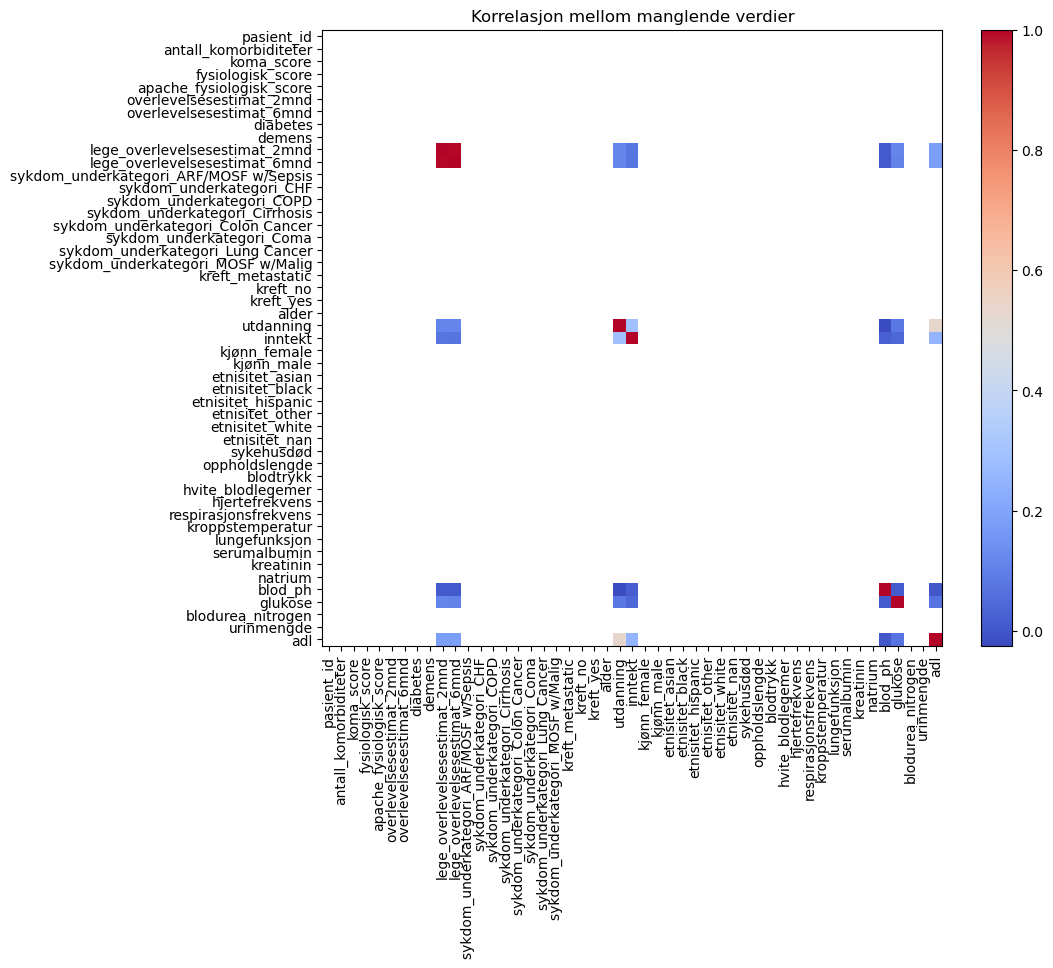

In [202]:
missing_corr = df.isnull().corr()

plt.figure(figsize=(10, 8))  
plt.imshow(missing_corr, cmap='coolwarm', interpolation='none', aspect='auto') #Heatmap
plt.colorbar() 
plt.title('Korrelasjon mellom manglende verdier') 

plt.xticks(np.arange(len(missing_corr.columns)), missing_corr.columns, rotation=90)
plt.yticks(np.arange(len(missing_corr.columns)), missing_corr.columns)

plt.show()


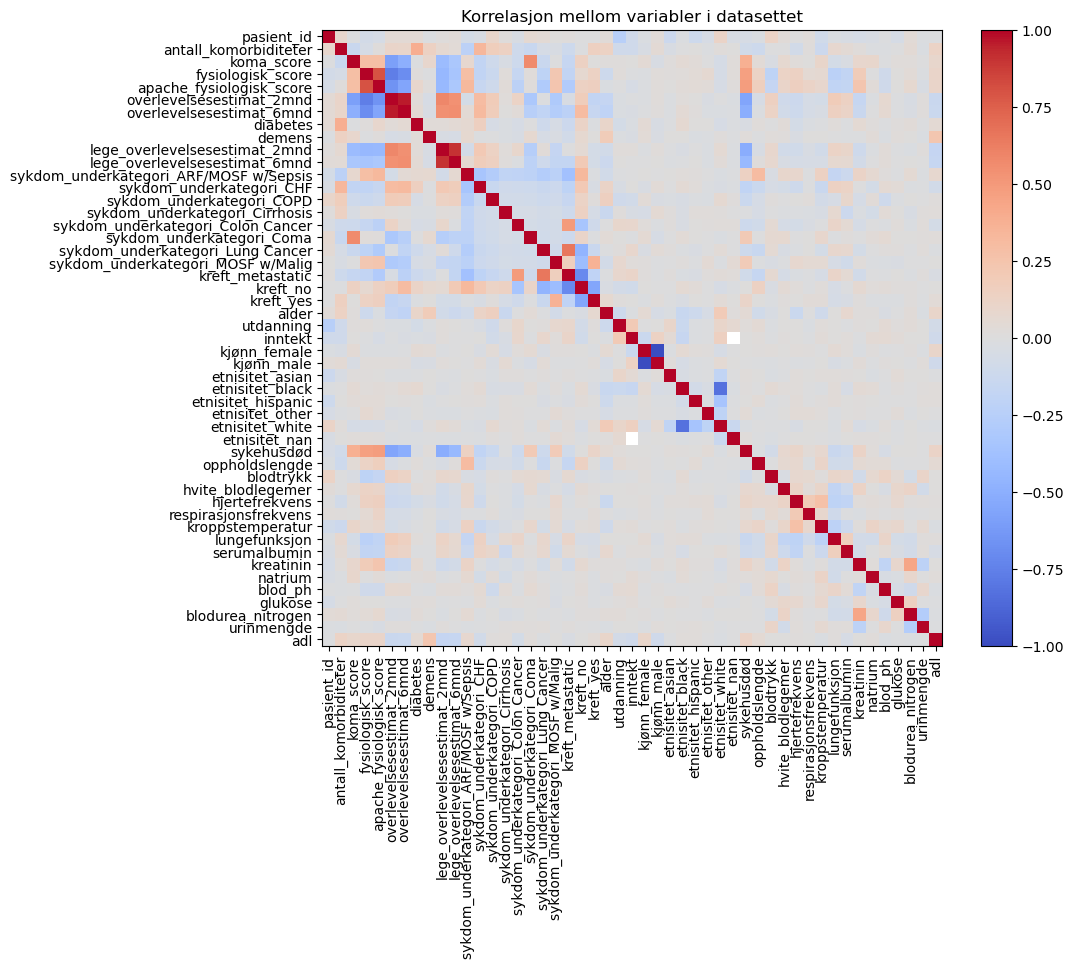

In [203]:
corr_matrix =train_df.corr()

plt.figure(figsize=(10, 8))  
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto') #Heatmap
plt.colorbar() 
plt.title('Korrelasjon mellom variabler i datasettet') 

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

Boxplot av kontinuerlige verdier:  

In [204]:
continuous = ['antall_komorbiditeter', 'koma_score', 'fysiologisk_score', 'apache_fysiologisk_score', 'overlevelsesestimat_2mnd', 
                'overlevelsesestimat_6mnd', 'alder', 'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens','respirasjonsfrekvens', 
               'kroppstemperatur', 'lungefunksjon','serumalbumin',  'kreatinin', 'natrium', 'blod_ph','glukose', 'blodurea_nitrogen', 'adl','urinmengde']


    
for column in continuous:
    fig = px.box(train_df[column], title = (f'Boxplot for {column}'))
    fig.update_layout(xaxis_title=column,
                      yaxis_title='Verdi')
    fig.show()
    
    

Kan nå fjerne uteliggere

Dette gjøres for å fjerne verdier som ligger langt utenfor normalfordelingen av dataene, noe som kan forbedre analysene eller modelleringen din

In [205]:

# for column in continuous:
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
    
#     # Fjerner uteliggere
#     df[column] = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)][column]

# for column in continuous:
#     fig = px.box(X_train[column], title = (f'Boxplot for {column}'))
#     fig.update_layout(xaxis_title=column,
#                       yaxis_title='Verdi')
#     fig.show()
    


Korrelasjonsmatrise Alder og oppholdslengde

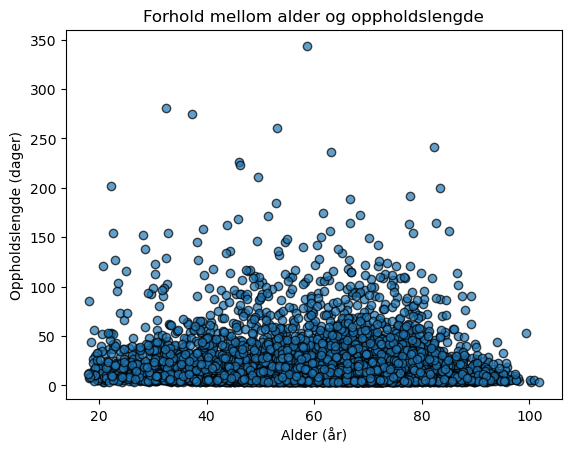

In [206]:
plt.scatter(df['alder'], df['oppholdslengde'], alpha=0.7, edgecolor='k')
plt.title('Forhold mellom alder og oppholdslengde')
plt.xlabel('Alder (år)')
plt.ylabel('Oppholdslengde (dager)')
plt.show()

Korrelasjon mellom fysiologisk score og oppholdslengde

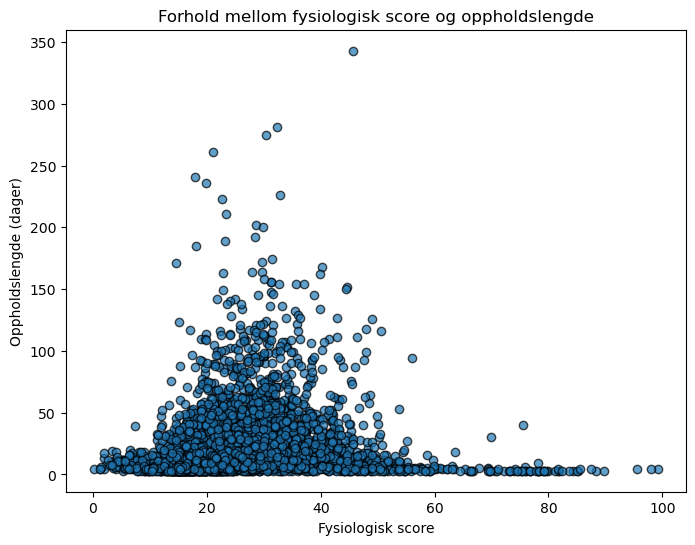

In [207]:

plt.figure(figsize=(8,6))
plt.scatter(df['fysiologisk_score'], df['oppholdslengde'], alpha=0.7, edgecolor='k')
plt.title('Forhold mellom fysiologisk score og oppholdslengde')
plt.xlabel('Fysiologisk score')
plt.ylabel('Oppholdslengde (dager)')
plt.show()
